In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"Рабочая директория: {Path.cwd()}")

Python: 3.10.0
pandas: 2.3.3
numpy: 2.2.6
Рабочая директория: c:\Users\linat\Desktop\Автоматизация процессов разработки и тестирования моделей машинного обучения


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

directories = [
    "data/raw",
    "data/processed",
    "models",
    "notebooks",
    "",
    "tests",
    "reports/figures",
]

for directory in directories:
    (PROJECT_ROOT / directory).mkdir(parents=True, exist_ok=True)

print("Структура проекта создана:\n")

for directory in directories:
    path = PROJECT_ROOT / directory
    print(f"✓ {path.relative_to(PROJECT_ROOT)}")

Структура проекта создана:

✓ data\raw
✓ data\processed
✓ models
✓ notebooks
✓ src
✓ tests
✓ reports\figures


In [3]:
import importlib.util

if importlib.util.find_spec("kagglehub") is None:
    print("kagglehub не установлен")
else:
    import kagglehub
    print(f"kagglehub установлен: {kagglehub.__version__}")

kagglehub установлен: 1.0.2


In [4]:
import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download(
    "uciml/default-of-credit-card-clients-dataset"
)

dataset_path = Path(dataset_path)

print(f"Датасет загружен в: {dataset_path}")
print("\nСодержимое:")

for file in dataset_path.iterdir():
    print(f"✓ {file.name}")

100%|██████████| 0.98M/0.98M [00:00<00:00, 2.15MB/s]

Extracting files...
Датасет загружен в: C:\Users\linat\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1

Содержимое:
✓ UCI_Credit_Card.csv


In [5]:
import shutil
from pathlib import Path

# Определяю корень проекта
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

source_file = dataset_path / "UCI_Credit_Card.csv"
raw_data_dir = PROJECT_ROOT / "data" / "raw"
raw_data_dir.mkdir(parents=True, exist_ok=True)

raw_file = raw_data_dir / "UCI_Credit_Card.csv"

shutil.copy2(source_file, raw_file)

print(f"Исходный файл сохранён: {raw_file}")
print(f"Размер: {raw_file.stat().st_size / 1024**2:.2f} MB")
print(f"Файл существует: {raw_file.exists()}")

Исходный файл сохранён: c:\Users\linat\Desktop\Автоматизация процессов разработки и тестирования моделей машинного обучения\data\raw\UCI_Credit_Card.csv
Размер: 2.73 MB
Файл существует: True


In [6]:
df = pd.read_csv(raw_file)

print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print("\nПервые 5 строк:")

display(df.head())

print("\nНазвания столбцов:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

Размер датасета: 30,000 строк × 25 столбцов

Первые 5 строк:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



Названия столбцов:
 1. ID
 2. LIMIT_BAL
 3. SEX
 4. EDUCATION
 5. MARRIAGE
 6. AGE
 7. PAY_0
 8. PAY_2
 9. PAY_3
10. PAY_4
11. PAY_5
12. PAY_6
13. BILL_AMT1
14. BILL_AMT2
15. BILL_AMT3
16. BILL_AMT4
17. BILL_AMT5
18. BILL_AMT6
19. PAY_AMT1
20. PAY_AMT2
21. PAY_AMT3
22. PAY_AMT4
23. PAY_AMT5
24. PAY_AMT6
25. default.payment.next.month


In [7]:
print("ТИПЫ ДАННЫХ")
print("-" * 50)
print(df.dtypes)

print("\nПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
print("-" * 50)

missing = df.isna().sum()
print(missing[missing > 0] if (missing > 0).any() else "Пропущенных значений нет.")

print("\nДУБЛИКАТЫ")
print("-" * 50)
print(f"Полных дубликатов строк: {df.duplicated().sum()}")

print("\nУНИКАЛЬНОСТЬ ID")
print("-" * 50)
print(f"Уникальных ID: {df['ID'].nunique():,}")
print(f"Всего строк:     {len(df):,}")
print(f"Дубликатов ID:   {df['ID'].duplicated().sum()}")

ТИПЫ ДАННЫХ
--------------------------------------------------
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.mont

УНИКАЛЬНЫЕ ЗНАЧЕНИЯ TARGET
--------------------------------------------------
[np.int64(0), np.int64(1)]

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
--------------------------------------------------


,Количество,"Доля, %"
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


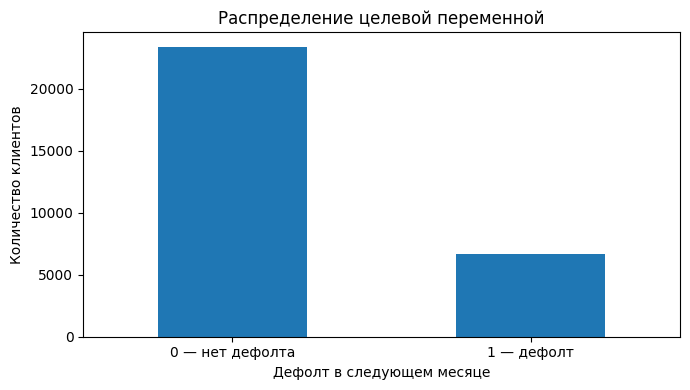

In [8]:
# Задаю имя целевой переменной
target = "default.payment.next.month"

# Проверяю уникальные значения целевой переменной
print("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ TARGET")
print("-" * 50)
print(sorted(df[target].unique()))

# Подсчитываю количество наблюдений каждого класса
target_counts = df[target].value_counts().sort_index()

# Рассчитываю долю каждого класса
target_share = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Количество": target_counts,
    "Доля, %": target_share.round(2)
})

print("\nРАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("-" * 50)
display(target_summary)

# Строю распределение классов
ax = target_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Распределение целевой переменной")
ax.set_xlabel("Дефолт в следующем месяце")
ax.set_ylabel("Количество клиентов")
ax.set_xticklabels(["0 — нет дефолта", "1 — дефолт"], rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Задаю признаки, значения которых представлены категориальными кодами
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

# Задаю признаки истории статуса платежей
payment_status_features = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ")
print("=" * 60)

for column in categorical_features:
    print(f"\n{column}")
    print("-" * 30)
    
    counts = df[column].value_counts().sort_index()
    shares = df[column].value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "Количество": counts,
        "Доля, %": shares.round(2)
    })
    
    display(summary)

print("\nСТАТУСЫ ПОГАШЕНИЯ")
print("=" * 60)

for column in payment_status_features:
    print(
        f"{column:5s}: "
        f"min = {df[column].min():2d}, "
        f"max = {df[column].max():2d}, "
        f"значения = {sorted(df[column].unique())}"
    )

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ

SEX
------------------------------


,Количество,"Доля, %"
SEX,,
1,11888,39.63
2,18112,60.37



EDUCATION
------------------------------


,Количество,"Доля, %"
EDUCATION,,
0,14,0.05
1,10585,35.28
2,14030,46.77
3,4917,16.39
4,123,0.41
5,280,0.93
6,51,0.17



MARRIAGE
------------------------------


,Количество,"Доля, %"
MARRIAGE,,
0,54,0.18
1,13659,45.53
2,15964,53.21
3,323,1.08



СТАТУСЫ ПОГАШЕНИЯ
PAY_0: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: min = -2, max =  8, значения = [np.int64(-2), np.int64(-1), np.int6

In [10]:
# Проверяю распределение кодов признака SEX
print("SEX")
print("-" * 50)
display(
    pd.DataFrame({
        "Количество": df["SEX"].value_counts().sort_index(),
        "Доля, %": (
            df["SEX"]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })
)

# Задаю основные числовые признаки
numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

# Рассчитываю основные описательные статистики
numeric_summary = df[numeric_features].describe().T

# Оставляю показатели, необходимые для первичного анализа диапазонов
numeric_summary = numeric_summary[
    ["min", "25%", "50%", "mean", "75%", "max"]
]

display(numeric_summary.round(2))

SEX
--------------------------------------------------


,Количество,"Доля, %"
SEX,,
1,11888,39.63
2,18112,60.37


,min,25%,50%,mean,75%,max
LIMIT_BAL,10000.0,50000.00,140000.0,167484.32,240000.00,1000000.0
AGE,21.0,28.00,34.0,35.49,41.00,79.0
BILL_AMT1,-165580.0,3558.75,22381.5,51223.33,67091.00,964511.0
BILL_AMT2,-69777.0,2984.75,21200.0,49179.08,64006.25,983931.0
BILL_AMT3,-157264.0,2666.25,20088.5,47013.15,60164.75,1664089.0
BILL_AMT4,-170000.0,2326.75,19052.0,43262.95,54506.00,891586.0
BILL_AMT5,-81334.0,1763.00,18104.5,40311.40,50190.50,927171.0
BILL_AMT6,-339603.0,1256.00,17071.0,38871.76,49198.25,961664.0
PAY_AMT1,0.0,1000.00,2100.0,5663.58,5006.00,873552.0
PAY_AMT2,0.0,833.00,2009.0,5921.16,5000.00,1684259.0


In [11]:
# Задаю категориальные признаки для анализа связи с дефолтом
features_to_analyze = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0"
]

for feature in features_to_analyze:
    # Рассчитываю количество клиентов и долю дефолтов
    summary = (
        df.groupby(feature)[target]
        .agg(
            clients="count",
            defaults="sum",
            default_rate="mean"
        )
    )

    # Перевожу долю дефолтов в проценты
    summary["default_rate"] = (
        summary["default_rate"] * 100
    ).round(2)

    print(f"\n{feature}")
    print("-" * 60)
    display(summary)


SEX
------------------------------------------------------------


,clients,defaults,default_rate
SEX,,,
1,11888,2873,24.17
2,18112,3763,20.78



EDUCATION
------------------------------------------------------------


,clients,defaults,default_rate
EDUCATION,,,
0,14,0,0.00
1,10585,2036,19.23
2,14030,3330,23.73
3,4917,1237,25.16
4,123,7,5.69
5,280,18,6.43
6,51,8,15.69



MARRIAGE
------------------------------------------------------------


,clients,defaults,default_rate
MARRIAGE,,,
0,54,5,9.26
1,13659,3206,23.47
2,15964,3341,20.93
3,323,84,26.01



PAY_0
------------------------------------------------------------


,clients,defaults,default_rate
PAY_0,,,
-2,2759,365,13.23
-1,5686,954,16.78
0,14737,1888,12.81
1,3688,1252,33.95
2,2667,1844,69.14
3,322,244,75.78
4,76,52,68.42
5,26,13,50.00
6,11,6,54.55


In [12]:
# Создаю копию данных для экспериментов с Feature Engineering
df_fe = df.copy()

# Задаю группы признаков за последние 6 месяцев
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

# Создаю агрегированные признаки по истории платежей
df_fe["AVG_BILL_AMT"] = df_fe[bill_cols].mean(axis=1)
df_fe["AVG_PAY_AMT"] = df_fe[payment_cols].mean(axis=1)

# Считаю количество месяцев с просрочкой
df_fe["DELAY_MONTHS"] = (df_fe[pay_status_cols] > 0).sum(axis=1)

# Вычисляю максимальную зафиксированную просрочку
df_fe["MAX_DELAY"] = df_fe[pay_status_cols].max(axis=1)

# Создаю отношение среднего счёта к кредитному лимиту
df_fe["CREDIT_UTILIZATION"] = (
    df_fe["AVG_BILL_AMT"] / df_fe["LIMIT_BAL"]
)

# Выполняю биннинг возраста
df_fe["AGE_GROUP"] = pd.cut(
    df_fe["AGE"],
    bins=[20, 30, 40, 50, 60, float("inf")],
    labels=["21-30", "31-40", "41-50", "51-60", "61+"],
    include_lowest=True
)

# Проверяю созданные признаки
engineered_features = [
    "AVG_BILL_AMT",
    "AVG_PAY_AMT",
    "DELAY_MONTHS",
    "MAX_DELAY",
    "CREDIT_UTILIZATION",
    "AGE_GROUP"
]

display(df_fe[engineered_features].head())

print("\nКоличество пропусков:")
display(df_fe[engineered_features].isna().sum())

print("\nДиапазоны числовых новых признаков:")
display(
    df_fe[
        [
            "AVG_BILL_AMT",
            "AVG_PAY_AMT",
            "DELAY_MONTHS",
            "MAX_DELAY",
            "CREDIT_UTILIZATION"
        ]
    ].describe().T.round(3)
)

print("\nРаспределение возрастных групп:")
display(df_fe["AGE_GROUP"].value_counts().sort_index())

,AVG_BILL_AMT,AVG_PAY_AMT,DELAY_MONTHS,MAX_DELAY,CREDIT_UTILIZATION,AGE_GROUP
0,1284.000000,114.833333,2,2,0.064200,21-30
1,2846.166667,833.333333,2,2,0.023718,21-30
2,16942.166667,1836.333333,0,0,0.188246,31-40
3,38555.666667,1398.000000,0,0,0.771113,31-40
4,18223.166667,9841.500000,0,0,0.364463,51-60



Количество пропусков:


AVG_BILL_AMT          0
AVG_PAY_AMT           0
DELAY_MONTHS          0
MAX_DELAY             0
CREDIT_UTILIZATION    0
AGE_GROUP             0
dtype: int64


Диапазоны числовых новых признаков:


,count,mean,std,min,25%,50%,75%,max
AVG_BILL_AMT,30000.0,44976.945,63260.722,-56043.167,4781.333,21051.833,57104.417,877313.833
AVG_PAY_AMT,30000.0,5275.232,10137.946,0.000,1113.292,2397.167,5583.917,627344.333
DELAY_MONTHS,30000.0,0.834,1.554,0.000,0.000,0.000,1.000,6.000
MAX_DELAY,30000.0,0.439,1.345,-2.000,0.000,0.000,2.000,8.000
CREDIT_UTILIZATION,30000.0,0.373,0.352,-0.233,0.030,0.285,0.688,5.364



Распределение возрастных групп:


AGE_GROUP
21-30    11013
31-40    10713
41-50     6005
51-60     1997
61+        272
Name: count, dtype: int64

ДЕФОЛТ В ЗАВИСИМОСТИ ОТ КОЛИЧЕСТВА МЕСЯЦЕВ С ПРОСРОЧКОЙ
----------------------------------------------------------------------


,clients,defaults,default_rate
DELAY_MONTHS,,,
0,19931,2334,11.71
1,4426,1320,29.82
2,1899,736,38.76
3,1154,587,50.87
4,951,545,57.31
5,298,171,57.38
6,1341,943,70.32



ДЕФОЛТ ПО ВОЗРАСТНЫМ ГРУППАМ
----------------------------------------------------------------------


,clients,defaults,default_rate
AGE_GROUP,,,
21-30,11013,2471,22.44
31-40,10713,2189,20.43
41-50,6005,1399,23.30
51-60,1997,504,25.24
61+,272,73,26.84


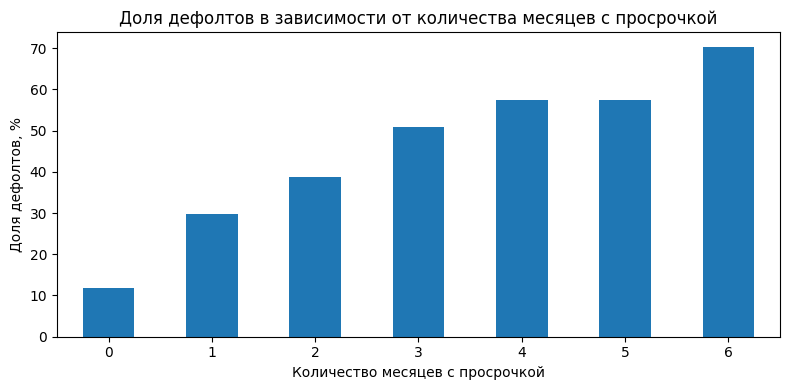

In [13]:
# Анализирую долю дефолтов в зависимости от количества месяцев с просрочкой
delay_default = (
    df_fe.groupby("DELAY_MONTHS", observed=False)[target]
    .agg(
        clients="count",
        defaults="sum",
        default_rate="mean"
    )
)

# Перевожу долю дефолтов в проценты
delay_default["default_rate"] = (
    delay_default["default_rate"] * 100
).round(2)

print("ДЕФОЛТ В ЗАВИСИМОСТИ ОТ КОЛИЧЕСТВА МЕСЯЦЕВ С ПРОСРОЧКОЙ")
print("-" * 70)
display(delay_default)


# Анализирую долю дефолтов по возрастным группам
age_default = (
    df_fe.groupby("AGE_GROUP", observed=False)[target]
    .agg(
        clients="count",
        defaults="sum",
        default_rate="mean"
    )
)

# Перевожу долю дефолтов в проценты
age_default["default_rate"] = (
    age_default["default_rate"] * 100
).round(2)

print("\nДЕФОЛТ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("-" * 70)
display(age_default)


# Строю график зависимости доли дефолтов от количества месяцев с просрочкой
ax = delay_default["default_rate"].plot(
    kind="bar",
    figsize=(8, 4)
)

ax.set_title("Доля дефолтов в зависимости от количества месяцев с просрочкой")
ax.set_xlabel("Количество месяцев с просрочкой")
ax.set_ylabel("Доля дефолтов, %")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Выводы первичного анализа данных

Датасет содержит 30 000 наблюдений и 25 исходных признаков, включая целевую переменную `default.payment.next.month`.

Основные результаты анализа:

- пропущенные значения отсутствуют;
- полные дубликаты отсутствуют;
- `ID` уникален для каждого наблюдения и является идентификатором, поэтому не должен использоваться как предиктор модели;
- целевая переменная бинарная: 77,88% клиентов не имеют дефолта и 22,12% имеют дефолт в следующем месяце;
- наблюдается умеренный дисбаланс классов, поэтому для оценки модели необходимо использовать ROC-AUC, Precision, Recall и F1-score;
- в `EDUCATION` присутствуют редкие/неопределённые категории `0`, `5`, `6`, а в `MARRIAGE` — категория `0`; на этапе подготовки данных они будут объединены в категорию `Other`;
- признаки `PAY_0`–`PAY_6` содержат значения от -2 до 8 и характеризуют историю статуса погашения;
- денежные признаки имеют выраженную асимметрию и экстремальные значения, которые не удаляются автоматически, поскольку могут представлять реальные финансовые наблюдения;
- на основе шестимесячной истории созданы агрегированные признаки `AVG_BILL_AMT`, `AVG_PAY_AMT`, `DELAY_MONTHS`, `MAX_DELAY` и `CREDIT_UTILIZATION`;
- выполнен биннинг возраста с созданием признака `AGE_GROUP`;
- `DELAY_MONTHS` демонстрирует выраженную связь с целевой переменной: доля дефолтов увеличивается с 11,71% при отсутствии месяцев с просрочкой до 70,32% при наличии просрочки во всех шести наблюдаемых месяцах.

Полученные результаты будут использованы при построении воспроизводимого этапа подготовки данных и ML-пайплайна.